# DATASCI 347 — Final Project (Revised)

## Predicting Relationship Cessation in UK Companies House PSC Data

**Goal:** Predict whether a controller→company `CONTROLS` relationship eventually ends (`ceased_on` exists).

**Data:** `rels2.csv` (edge table).

**Metrics:** ROC-AUC, PR-AUC, Accuracy/F1 at threshold 0.5, and Best-threshold F1.

**Outputs:**
- `results/tables/`
- `results/figures/`

### Local path
- rels2: `/Users/dw/Desktop/research/ch3_fixed_test/rels2.csv`


In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, average_precision_score,
    precision_recall_curve
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

os.makedirs("results/tables", exist_ok=True)
os.makedirs("results/figures", exist_ok=True)

In [2]:
rels_path = r"/Users/dw/Desktop/research/ch3_fixed_test/rels2.csv" 

## 1) Load and clean edges

In [3]:
usecols = [":START_ID", ":END_ID", ":TYPE", "natures_of_control", "notified_on", "ceased_on"]
try:
    rels = pd.read_csv(rels_path, usecols=lambda c: c in usecols, low_memory=False)
except Exception:
    rels = pd.read_csv(rels_path, usecols=lambda c: c in usecols, encoding="latin1", low_memory=False)

rels = rels.dropna(subset=[":START_ID", ":END_ID"]).copy()
rels[":TYPE"] = rels[":TYPE"].fillna("CONTROLS")
rels = rels[rels[":TYPE"].astype(str).str.upper().eq("CONTROLS")].copy()

rels.shape

(19998, 6)

## 2) Label and features

**Label:** `y = 1` if `ceased_on` is present.

**Features:**
- `nature_primary` (first token from `natures_of_control`, one-hot)
- `notified_year`, `notified_month`

In [4]:
rels["y"] = rels["ceased_on"].notna().astype(int)

def primary_nature(x):
    if pd.isna(x):
        return "MISSING"
    s = str(x).strip()
    if not s:
        return "MISSING"
    parts = [p.strip() for p in re.split(r"[;|,]", s) if p.strip()]
    return parts[0] if parts else "MISSING"

rels["nature_primary"] = rels["natures_of_control"].apply(primary_nature)

rels["notified_on"] = pd.to_datetime(rels["notified_on"], errors="coerce")
rels["notified_year"] = rels["notified_on"].dt.year.fillna(-1).astype(int)
rels["notified_month"] = rels["notified_on"].dt.month.fillna(-1).astype(int)

pos_rate = float(rels["y"].mean())
pos_rate

0.237023702370237

In [5]:
X_time = rels[["notified_year", "notified_month"]].copy()
X_nature = pd.get_dummies(rels[["nature_primary"]].fillna("MISSING"), drop_first=True)
X_full = pd.concat([X_time, X_nature], axis=1).fillna(0)
y = rels["y"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=347, stratify=y
)

X_full.shape, y.mean()

((19998, 42), 0.237023702370237)

## 3) Models

- Logistic Regression (scaled + `saga` + `class_weight='balanced'`)
- Random Forest (`class_weight='balanced'`)

In [6]:
def best_f1_threshold(y_true, prob):
    prec, rec, thr = precision_recall_curve(y_true, prob)
    f1s = 2 * prec * rec / (prec + rec + 1e-12)
    if len(thr) > 0:
        idx = int(np.argmax(f1s[:-1]))
        return float(thr[idx]), float(f1s[:-1][idx])
    return 0.5, float(f1_score(y_true, (prob >= 0.5).astype(int), zero_division=0))

def eval_row(name, y_true, prob):
    pred05 = (prob >= 0.5).astype(int)
    acc05 = float(accuracy_score(y_true, pred05))
    f105 = float(f1_score(y_true, pred05, zero_division=0))
    auc = float(roc_auc_score(y_true, prob))
    pr = float(average_precision_score(y_true, prob))
    thr, f1b = best_f1_threshold(y_true, prob)
    return {"model": name, "acc_thr0.5": acc05, "f1_thr0.5": f105, "roc_auc": auc, "pr_auc": pr, "best_thr_f1": thr, "f1_best_thr": f1b}

In [7]:
lr = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(solver="saga", max_iter=20000, class_weight="balanced"))
])
lr.fit(X_train, y_train)
p_lr = lr.predict_proba(X_test)[:, 1]

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=347,
    n_jobs=1,
    max_features="sqrt",
    class_weight="balanced"
)
rf.fit(X_train, y_train)
p_rf = rf.predict_proba(X_test)[:, 1]

results = pd.DataFrame([
    eval_row("LogReg_balanced", y_test, p_lr),
    eval_row("RF_balanced", y_test, p_rf),
])

results

,model,acc_thr0.5,f1_thr0.5,roc_auc,pr_auc,best_thr_f1,f1_best_thr
0,LogReg_balanced,0.57350,0.425976,0.635158,0.350787,0.366220,0.430670
1,RF_balanced,0.61875,0.403131,0.630668,0.340737,0.389456,0.426667


## 4) PR curve and threshold–F1 curve

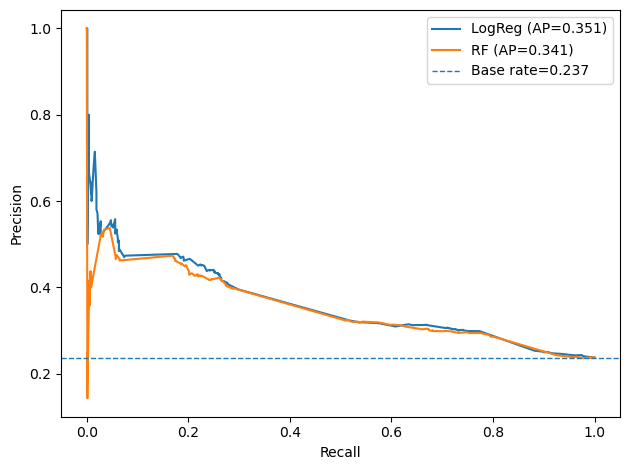

In [8]:
prec_lr, rec_lr, _ = precision_recall_curve(y_test, p_lr)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, p_rf)

plt.figure()
plt.plot(rec_lr, prec_lr, label=f"LogReg (AP={average_precision_score(y_test, p_lr):.3f})")
plt.plot(rec_rf, prec_rf, label=f"RF (AP={average_precision_score(y_test, p_rf):.3f})")
plt.axhline(pos_rate, linestyle="--", linewidth=1, label=f"Base rate={pos_rate:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.savefig("results/figures/pr_curve.png", dpi=200)
plt.show()

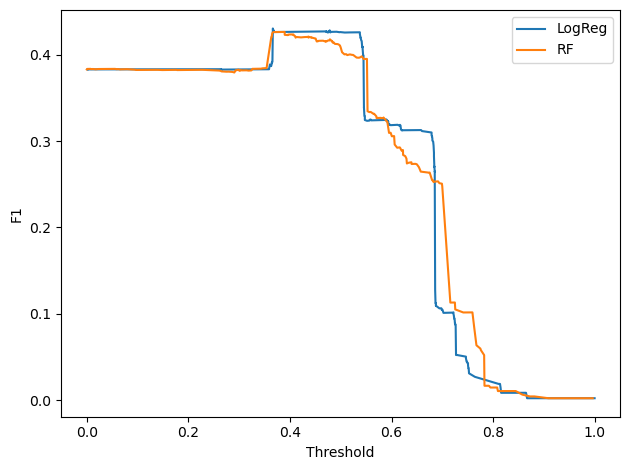

In [9]:
def thr_f1_curve(y_true, prob):
    prec, rec, thr = precision_recall_curve(y_true, prob)
    f1 = 2 * prec * rec / (prec + rec + 1e-12)
    return thr, f1[:-1]

thr_l, f1_l = thr_f1_curve(y_test, p_lr)
thr_r, f1_r = thr_f1_curve(y_test, p_rf)

plt.figure()
plt.plot(thr_l, f1_l, label="LogReg")
plt.plot(thr_r, f1_r, label="RF")
plt.xlabel("Threshold")
plt.ylabel("F1")
plt.legend()
plt.tight_layout()
plt.savefig("results/figures/threshold_f1.png", dpi=200)
plt.show()

## 5) Ablation study

Compare feature sets:
- `time_only`
- `nature_only`
- `time_plus_nature`

In [10]:
def fit_eval_for_X(X):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=347, stratify=y)

    lr = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", LogisticRegression(solver="saga", max_iter=20000, class_weight="balanced"))
    ])
    lr.fit(Xtr, ytr)
    p_lr = lr.predict_proba(Xte)[:,1]

    rf = RandomForestClassifier(n_estimators=500, random_state=347, n_jobs=1, max_features="sqrt", class_weight="balanced")
    rf.fit(Xtr, ytr)
    p_rf = rf.predict_proba(Xte)[:,1]

    return pd.DataFrame([
        eval_row("LogReg_balanced", yte, p_lr),
        eval_row("RF_balanced", yte, p_rf),
    ])

abl_rows = []
for name, Xset in [("time_only", X_time.fillna(0)), ("nature_only", X_nature.fillna(0)), ("time_plus_nature", X_full)]:
    tmp = fit_eval_for_X(Xset)
    tmp.insert(0, "features", name)
    abl_rows.append(tmp)

ablation = pd.concat(abl_rows, ignore_index=True)
ablation

,features,model,acc_thr0.5,f1_thr0.5,roc_auc,pr_auc,best_thr_f1,f1_best_thr
0,time_only,LogReg_balanced,0.39425,0.352312,0.501715,0.242644,0.489612,0.383185
1,time_only,RF_balanced,0.40275,0.348514,0.496665,0.241351,0.008321,0.383263
2,nature_only,LogReg_balanced,0.57375,0.426891,0.635629,0.333844,0.477315,0.427287
3,nature_only,RF_balanced,0.57400,0.425876,0.635396,0.332418,0.476197,0.427419
4,time_plus_nature,LogReg_balanced,0.57350,0.425976,0.635158,0.350787,0.366220,0.430670
5,time_plus_nature,RF_balanced,0.61875,0.403131,0.630668,0.340737,0.389456,0.426667


## 6) Save tables

In [11]:
results.to_csv("results/tables/main_results.csv", index=False)
ablation.to_csv("results/tables/ablation_results.csv", index=False)
pd.Series({"positive_rate": pos_rate, "n_rows": len(rels)}).to_csv("results/tables/data_summary.csv")
